In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [18]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [19]:
data.shape

(200, 5)

In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [21]:
data['Annual_Income'] = data['Annual Income (k$)']
data['Spending_Score'] = data['Spending Score (1-100)']
data = data.drop(['Spending Score (1-100)','Annual Income (k$)','CustomerID'],axis=1)

In [22]:
data.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [23]:
data.isna().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

In [24]:
data['Gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [25]:
data['Gender'] = data['Gender'].replace(['Male', 'Female'],[1,0])

In [26]:
data.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [27]:
cols_to_scale = ['Annual_Income','Spending_Score']

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[cols_to_scale])

data_scaled = pd.DataFrame(data=data_scaled,columns=cols_to_scale)
data_scaled

,Annual_Income,Spending_Score
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959
...,...,...
195,0.860656,0.795918
196,0.909836,0.275510
197,0.909836,0.744898
198,1.000000,0.173469


In [28]:
X = data_scaled.values

cluster = KMeans(n_clusters=3, max_iter=500,random_state=42).fit(X)
label = cluster.labels_ 

In [29]:
score = silhouette_score(X,label)
score

0.4498539603795658

In [30]:
scores = []

for k in range(2,11):
    model = KMeans(n_clusters=k,max_iter=500,random_state=42)
    label = model.fit_predict(data_scaled)
    score = silhouette_score(data_scaled,label)
    scores.append(score)
    print(f'k ={k}silhoutte score = {score}')

k =2silhoutte score = 0.3447138642257591
k =3silhoutte score = 0.4498539603795658
k =4silhoutte score = 0.4971506623868143
k =5silhoutte score = 0.5593469429051445
k =6silhoutte score = 0.5244046259750482
k =7silhoutte score = 0.48083628842905113
k =8silhoutte score = 0.47423530152553683
k =9silhoutte score = 0.4332042575649034
k =10silhoutte score = 0.44833378088523645


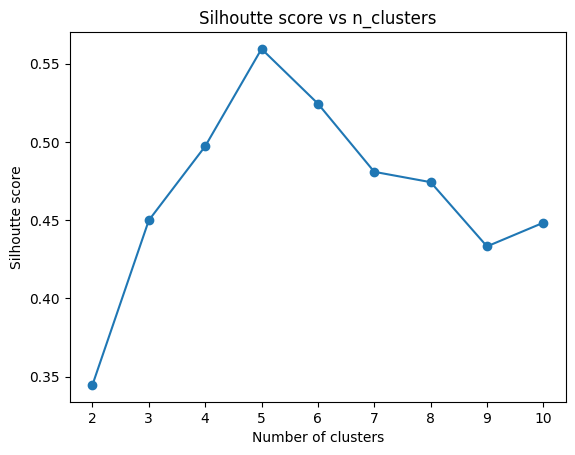

In [31]:
plt.plot(range(2,11),scores,marker = 'o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhoutte score")
plt.title("Silhoutte score vs n_clusters")
plt.show()

In [32]:
model = KMeans(n_clusters=5,max_iter=500,random_state=42).fit(data_scaled)
label = model.labels_
score = silhouette_score(data_scaled,label)
score

0.5593469429051445

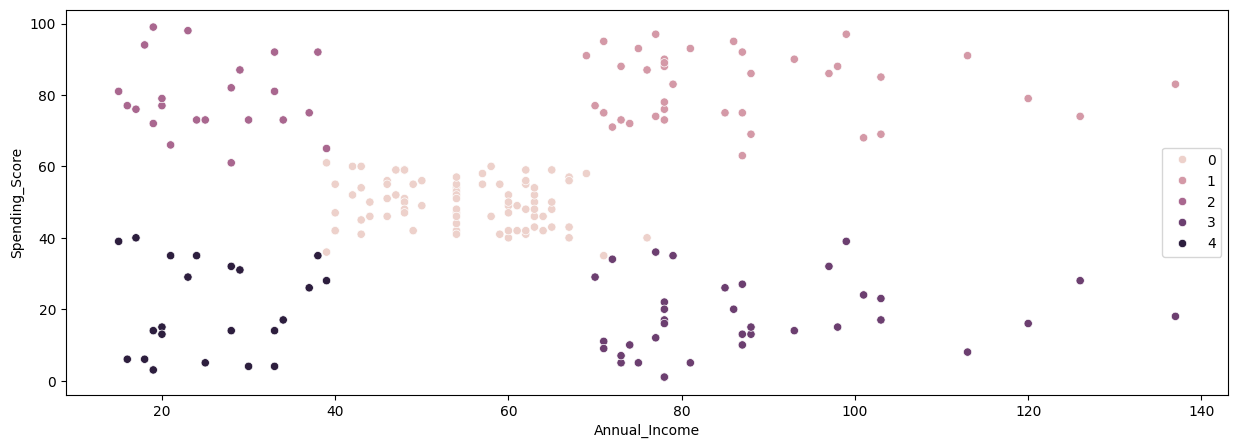

In [33]:

plt.figure(figsize=(15,5))
sns.scatterplot(data=data,x='Annual_Income',y='Spending_Score',hue=label)
plt.show()

In [34]:
data['cluster'] = label
data

,Gender,Age,Annual_Income,Spending_Score,cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,3
197,1,32,126,74,1
198,1,32,137,18,3


<Axes: xlabel='cluster', ylabel='count'>

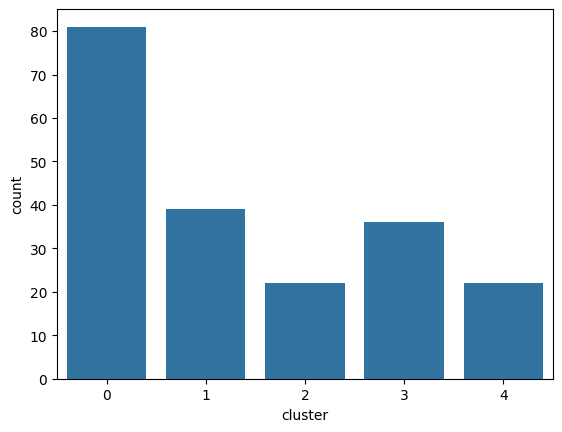

In [35]:
sns.countplot(data=data, x='cluster')

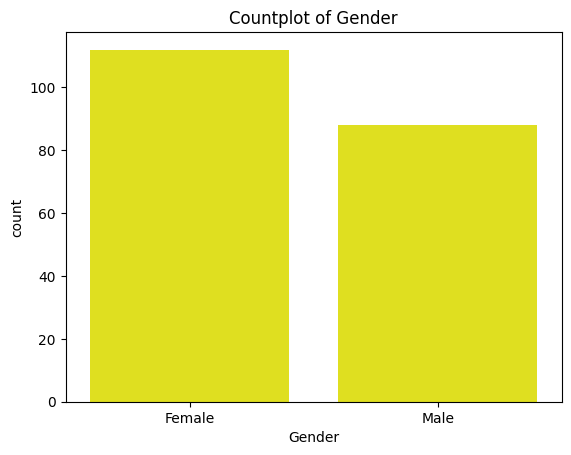

In [46]:
sns.countplot(x='Gender',data=data,color='yellow')
plt.title('Countplot of Gender')
plt.xticks(ticks=[0,1],labels=['Female','Male'])
plt.show()

<Axes: xlabel='cluster', ylabel='Spending_Score'>

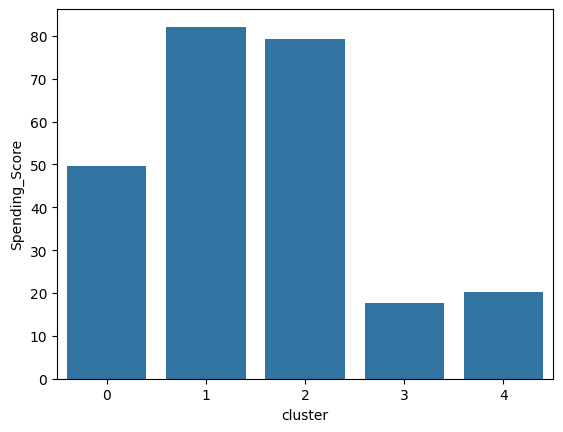

In [36]:
sns.barplot(data,x='cluster',y='Spending_Score',errorbar=None)

<Axes: xlabel='cluster', ylabel='Annual_Income'>

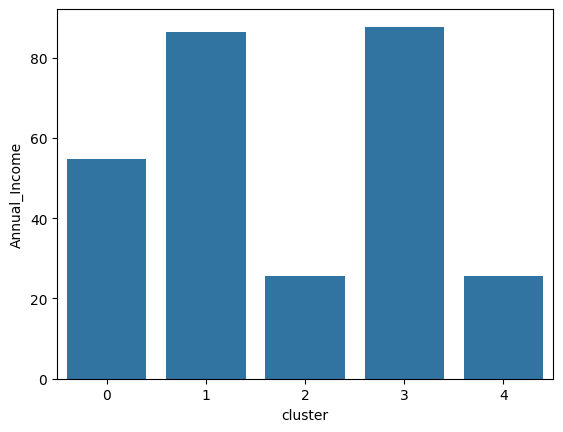

In [37]:
sns.barplot(data=data,x='cluster',y='Annual_Income',errorbar=None)

<Axes: xlabel='Age', ylabel='Count'>

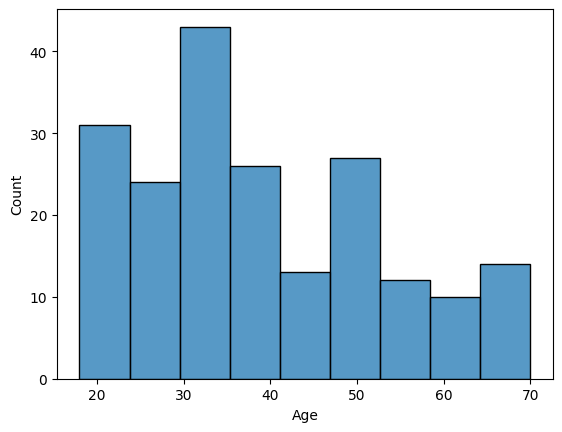

In [39]:
sns.histplot(x='Age',data=data)